In [1]:
from langgraph.graph import MessagesState
from groq import Groq
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

In [2]:
model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.3
)

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 2

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

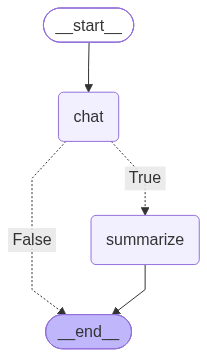

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [11]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [12]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='54774aba-bb22-48d8-9b7e-af756dd7f0dc')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Sure! Quantum physics is a fascinating field that explores the behavior of matte


In [13]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='54774aba-bb22-48d8-9b7e-af756dd7f0dc'), AIMessage(content='Sure! Quantum physics is a fascinating field that explores the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and even sub‑atomic particles. It’s full of counterintuitive concepts like wave‑particle duality, superposition, entanglement, and the uncertainty principle.\n\nWhat would you like to dive into? Here are a few options:\n\n1. **Foundational principles** – a quick tour of the key ideas and equations.  \n2. **Historical development** – how quantum theory evolved from Planck to Schrödinger to modern experiments.  \n3. **Applications** – quantum computing, cryptography, imaging, or materials science.  \n4. **Specific phenomena** – tunneling, quantum interference, or the double‑slit experiment.  \n5. **Current research** – cutting‑edge experiments or theoretical breakthroughs.  \n\nLet me know which direct

In [14]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='How is Albert Einstien related?', additional_kwargs={}, response_metadata={}, id='fba710c0-c3b9-4144-ba94-1cb047f7abb3'), AIMessage(content='### Albert\u202fEinstein and Quantum Physics: A Quick Overview\n\n| **Area** | **Einstein’s Contribution** | **Why It Matters** |\n|----------|-----------------------------|--------------------|\n| **Photoelectric Effect (1905)** | Proposed that light is made of discrete packets (quanta) of energy, \\(E = h\\nu\\). | Earned him the 1921 Nobel Prize in Physics and laid the groundwork for quantum theory. |\n| **Specific Heat of Solids (1907)** | Used quantized vibrational modes (phonons) to explain why solids’ heat capacities drop at low temperatures. | Demonstrated that quantization is not just a property of light but of matter too. |\n| **Brownian Motion (1905)** | Provided statistical evidence for atoms and molecules, supporting the reality of the quantum world. | Strengthened the physical reality of quantum entities. |\n| 

In [15]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='What are some of Einstien"s famous work', additional_kwargs={}, response_metadata={}, id='aab13139-e43f-492c-9b81-cff72fd2804e'), AIMessage(content='**Albert\u202fEinstein’s most celebrated works (and the ideas they introduced)**  \n\n| Year | Title / Contribution | Why it’s famous |\n|------|----------------------|-----------------|\n| **1905** | *On a Heuristic Viewpoint Concerning the Production and Transformation of Light* (photoelectric effect) | First quantitative evidence that light is quantized (photons). Nobel Prize in Physics, 1921. |\n| **1905** | *On the Electrodynamics of Moving Bodies* (Special Relativity) | Replaced Newtonian mechanics with Lorentz‑invariant laws; introduced \\(E=mc^2\\). |\n| **1905** | *Does the Inertia of a Body Depend on Its Energy Content?* | Derived \\(E=mc^2\\) from special relativity. |\n| **1907** | *The Quantum Theory of the Specific Heat of Solids* | Applied quantization to lattice vibrations (phonons). |\n| **1915** | *